In [1]:
%pip install tensorflow


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
from tensorflow.keras.applications import MobileNetV3Small, EfficientNetB0
model_mobilenet = MobileNetV3Small(weights='imagenet')
model_efficientnet = EfficientNetB0(weights='imagenet')


/Users/romeshjain/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:34: NotOpenSSLWarning: urllib3 v2.0 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/romeshjain/Library/Python/3.9/lib/python/site-packages/keras/src/applications/mobilenet_v3.py:452: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


In [4]:
%pip install torch torchvision


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
from torchvision.models import mobilenet_v3_small, efficientnet_b0
model_mobilenet = mobilenet_v3_small(pretrained=True)
model_efficientnet = efficientnet_b0(pretrained=True)


/Users/romeshjain/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/romeshjain/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/Users/romeshjain/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGEN

In [6]:
import os
from PIL import Image
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
import torch


CNRPARK_PATH = "/Users/romeshjain/Desktop/DL Parking Allocation/Dataset/CNRPark-Patches-150x150"
CNREXT_PATH = "/Users/romeshjain/Desktop/DL Parking Allocation/Dataset/CNR-EXT-Patches-150x150"


transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# dataset class
class ParkingDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        
        # CNRPark-Patches
        for camera in ["A", "B"]:
            for label in ["free", "busy"]:
                label_path = os.path.join(root_dir, camera, label)
                for img_name in os.listdir(label_path):
                    img_path = os.path.join(label_path, img_name)
                    self.image_paths.append(img_path)
                    self.labels.append(0 if label == "free" else 1)

    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

# DataLoader
train_dataset = ParkingDataset(CNRPARK_PATH, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


In [8]:
import torch.nn as nn
import torch.optim as optim
from torchvision.models import mobilenet_v3_small, efficientnet_b0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#pre-trained weights
mobilenet = mobilenet_v3_small(pretrained=True)
efficientnet = efficientnet_b0(pretrained=True)

# binary classification (free/busy)
mobilenet.classifier[3] = nn.Linear(mobilenet.classifier[3].in_features, 2)
efficientnet.classifier[1] = nn.Linear(efficientnet.classifier[1].in_features, 2)

mobilenet = mobilenet.to(device)
efficientnet = efficientnet.to(device)

# loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer_mobilenet = optim.Adam(mobilenet.parameters(), lr=0.001)
optimizer_efficientnet = optim.Adam(efficientnet.parameters(), lr=0.001)


In [ ]:

epochs = 5
for epoch in range(epochs):
    mobilenet.train()  
    running_loss = 0.0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer_mobilenet.zero_grad()
        outputs = mobilenet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_mobilenet.step()
        
        running_loss += loss.item()

    
    torch.save(mobilenet.state_dict(), 'mobilenet_best_model1.pth')

    
    # if val_loss < best_val_loss:
    #     best_val_loss = val_loss
    #     torch.save(mobilenet.state_dict(), 'mobilenet_best_model.pth')
    
    print(f"Epoch {epoch+1}/{epochs}, Training Loss: {running_loss / len(train_loader)}")


torch.save(mobilenet.state_dict(), 'mobilenet_best_model1.pth')  


Epoch 1/5, Training Loss: 0.0504468361080948
Epoch 2/5, Training Loss: 0.019992962868287244
Epoch 3/5, Training Loss: 0.015346473231347935
Epoch 4/5, Training Loss: 0.007991650745369039
Epoch 5/5, Training Loss: 0.010965478103710737


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from PIL import Image
import os


from torchvision.models import mobilenet_v3_small


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mobilenet = mobilenet_v3_small(pretrained=False)  # pretrained=False
mobilenet.classifier[3] = nn.Linear(mobilenet.classifier[3].in_features, 2)
mobilenet.load_state_dict(torch.load('/Users/romeshjain/Desktop/DL Parking Allocation/mobilenet_best_model1.pth'))  
mobilenet = mobilenet.to(device)
mobilenet.eval()  

# Define transformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize images
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Custom dataset class (assuming similar structure as for EfficientNet)
class ParkingDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        
        # Load images and labels from folders
        for camera in ["A", "B"]:
            for label in ["free", "busy"]:
                label_path = os.path.join(root_dir, camera, label)
                for img_name in os.listdir(label_path):
                    img_path = os.path.join(label_path, img_name)
                    self.image_paths.append(img_path)
                    self.labels.append(0 if label == "free" else 1)

    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

# train, validation, and test sets
dataset = ParkingDataset("/Users/romeshjain/Desktop/DL Parking Allocation/Dataset/CNRPark-Patches-150x150", transform=transform)
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

# DataLoaders
batch_size = 8
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# loss function
criterion = nn.CrossEntropyLoss()


def evaluate(model, data_loader):
    model.eval()
    loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            batch_loss = criterion(outputs, labels)
            loss += batch_loss.item()
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = loss / len(data_loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy


val_loss, val_accuracy = evaluate(mobilenet, val_loader)
print(f"Validation Loss (MobileNet): {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%")


test_loss, test_accuracy = evaluate(mobilenet, test_loader)
print(f"Test Loss (MobileNet): {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")


/Users/romeshjain/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Validation Loss (MobileNet): 0.0102, Validation Accuracy: 99.68%
Test Loss (MobileNet): 0.0078, Test Accuracy: 99.68%


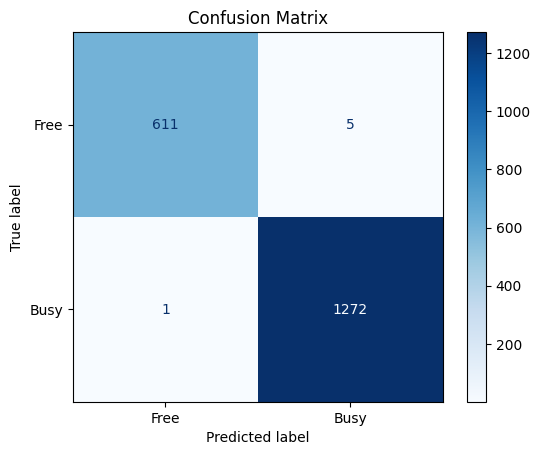

Classification Report:
              precision    recall  f1-score   support

        Free       1.00      0.99      1.00       616
        Busy       1.00      1.00      1.00      1273

    accuracy                           1.00      1889
   macro avg       1.00      1.00      1.00      1889
weighted avg       1.00      1.00      1.00      1889



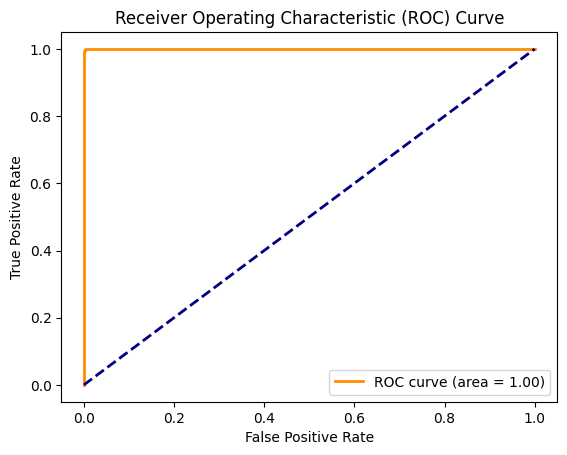

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc

# predictions and true labels from the test set
all_preds = []
all_labels = []
all_probs = []

mobilenet.eval()  
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = mobilenet(images)
        
        # ROC curve
        probs = torch.softmax(outputs, dim=1)[:, 1]  # Probability of 'busy' class
        all_probs.extend(probs.cpu().numpy())
        
        # Predictions and labels
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Free", "Busy"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=["Free", "Busy"]))


fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.show()
